In [1]:
import pandas as pd

col_names = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=col_names)
print(df.shape)
print(df['engine_id'].nunique())
df.head()

(20631, 26)
100


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
max_cycles = df.groupby('engine_id')['cycle'].transform('max')
df['RUL'] = max_cycles-df['cycle']
print(df.head())

   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_13  sensor_14  \
0    641.82   1589.70   1400.60     14.62  ...    2388.02    8138.62   
1    642.15   1591.82   1403.14     14.62  ...    2388.07    8131.49   
2    642.35   1587.99   1404.20     14.62  ...    2388.03    8133.23   
3    642.35   1582.79   1401.87     14.62  ...    2388.08    8133.83   
4    642.37   1582.85   1406.22     14.62  ...    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  \
0     8.4195       0.03        392       2388

In [4]:
df[df['engine_id'] == 1][['cycle', 'RUL']].tail()

,cycle,RUL
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


In [5]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
std_devs = df[sensor_cols].std()
print(std_devs)

sensor_1     0.000000e+00
sensor_2     5.000533e-01
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_7     8.850923e-01
sensor_8     7.098548e-02
sensor_9     2.208288e+01
sensor_10    0.000000e+00
sensor_11    2.670874e-01
sensor_12    7.375534e-01
sensor_13    7.191892e-02
sensor_14    1.907618e+01
sensor_15    3.750504e-02
sensor_16    3.469531e-18
sensor_17    1.548763e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    1.807464e-01
sensor_21    1.082509e-01
dtype: float64


In [6]:
constant_sensors = ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
df = df.drop(columns=constant_sensors)
print(df.shape)

(20631, 21)


In [7]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [col for col in df.columns if col not in ['engine_id', 'cycle', 'RUL']]

scaler = MinMaxScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [8]:
df[feature_cols].describe()

,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.499490,0.501959,0.0,0.443052,0.424746,0.450435,0.980321,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127
std,0.125708,0.244218,0.0,0.150618,0.133664,0.151935,0.138898,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.413793,0.333333,0.0,0.335843,0.331807,0.339467,1.000000,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361
50%,0.500000,0.500000,0.0,0.430723,0.415522,0.435348,1.000000,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443
75%,0.586207,0.750000,0.0,0.539157,0.508829,0.545324,1.000000,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
def create_sequences(engine_df, feature_cols, window_size):
    sequences = []
    labels = []
    
    for i in range(len(engine_df) - window_size + 1):
        seq = engine_df[feature_cols].iloc[i : i + window_size].values
        label = engine_df['RUL'].iloc[i + window_size - 1]
        sequences.append(seq)
        labels.append(label)
    
    return sequences, labels

In [10]:
engine_1_df = df[df['engine_id'] == 1].reset_index(drop=True)

window_size = 30
sequences, labels = create_sequences(engine_1_df, feature_cols, window_size)

print(len(sequences))
print(sequences[0].shape)
print(labels[0])

163
(30, 18)
162


In [12]:
cycle_counts = df.groupby('engine_id')['cycle'].max()
print(cycle_counts.min())
print((cycle_counts < window_size).sum())

128
0


In [13]:
all_sequences = []
all_labels = []

for engine_id in df['engine_id'].unique():
    engine_df = df[df['engine_id'] == engine_id].reset_index(drop=True)
    seqs, labs = create_sequences(engine_df, feature_cols, window_size)
    all_sequences.extend(seqs)
    all_labels.extend(labs)

print(len(all_sequences))
print(len(all_labels))

17731
17731


In [14]:
import numpy as np

X = np.array(all_sequences)
y = np.array(all_labels)

print(X.shape)
print(y.shape)

(17731, 30, 18)
(17731,)


In [15]:
train_engines = list(range(1, 81))   
val_engines = list(range(81, 101))  

X_train, y_train = [], []
X_val, y_val = [], []

for engine_id in df['engine_id'].unique():
    engine_df = df[df['engine_id'] == engine_id].reset_index(drop=True)
    seqs, labs = create_sequences(engine_df, feature_cols, window_size)
    
    if engine_id in train_engines:
        X_train.extend(seqs)
        y_train.extend(labs)
    else:
        X_val.extend(seqs)
        y_val.extend(labs)

X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(13818, 30, 18) (13818,)
(3913, 30, 18) (3913,)


In [18]:
from tensorflow import keras
from tensorflow import keras

model = keras.Sequential([
    keras.layers.LSTM(64, activation='tanh', input_shape=(window_size, len(feature_cols)), return_sequences=True),
    keras.layers.LSTM(32, activation='tanh'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 5966.4541 - mae: 60.4205 - val_loss: 5372.1460 - val_mae: 58.3308
Epoch 2/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 3453.8213 - mae: 48.1744 - val_loss: 5251.1963 - val_mae: 58.0142
Epoch 3/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 2535.3716 - mae: 38.7240 - val_loss: 2498.7893 - val_mae: 35.0155
Epoch 4/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 1128.8026 - mae: 23.4873 - val_loss: 2020.5486 - val_mae: 30.0688
Epoch 5/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 968.9346 - mae: 21.2460 - val_loss: 1746.4886 - val_mae: 27.4069
Epoch 6/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 903.5697 - mae: 20.3218 - val_loss: 1947.2491 - val_mae: 28.2222
Epoch 7/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 868.3044 - mae: 19.7412 - val_loss: 1873.1471 - val_mae: 27.6808
Epoch 8/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 834.6219 - mae: 19.2206 - val_loss: 1573.1824

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - loss: 744.2446 - mae: 17.9942 - val_loss: 1437.8564 - val_mae: 24.3862
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 708.6239 - mae: 17.6414 - val_loss: 1555.3815 - val_mae: 25.6099
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 723.0261 - mae: 17.8959 - val_loss: 1466.7772 - val_mae: 24.6889
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 690.5109 - mae: 17.5530 - val_loss: 1493.6378 - val_mae: 24.4853
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 680.7903 - mae: 17.2105 - val_loss: 1608.9653 - val_mae: 25.6485
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 672.3574 - mae: 17.1988 - val_loss: 1532.0594 - val_mae: 24.4330


In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_val)
y_pred = y_pred.flatten()

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"MAE: {mae:.2f} cycles")
print(f"R²: {r2:.4f}")

123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
MAE: 24.39 cycles
R²: 0.7119


In [23]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Cap RUL
cap = 125
df['RUL'] = df['RUL'].clip(upper=cap)

# Step 2: Rebuild sequences with capped labels
window_size = 30
train_engines = list(range(1, 81))
val_engines = list(range(81, 101))

X_train, y_train = [], []
X_val, y_val = [], []

for engine_id in df['engine_id'].unique():
    engine_df = df[df['engine_id'] == engine_id].reset_index(drop=True)
    seqs, labs = create_sequences(engine_df, feature_cols, window_size)
    
    if engine_id in train_engines:
        X_train.extend(seqs)
        y_train.extend(labs)
    else:
        X_val.extend(seqs)
        y_val.extend(labs)

X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

# Step 3: Rebuild model fresh (important - don't reuse old weights)
model = keras.Sequential([
    layers.LSTM(64, activation='tanh', input_shape=(window_size, len(feature_cols)), return_sequences=True),
    layers.LSTM(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 4: Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# Step 5: Evaluate
y_pred = model.predict(X_val).flatten()
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
print(f"MAE: {mae:.2f} cycles")
print(f"R²: {r2:.4f}")

(13818, 30, 18) (13818,) (3913, 30, 18) (3913,)
Epoch 1/50


c:\Users\suryansh raghav\OneDrive\Desktop\NASA_Predictive_Maintenance\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 4103.8154 - mae: 53.9912 - val_loss: 1957.3732 - val_mae: 40.0840
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 1748.4980 - mae: 37.1985 - val_loss: 1787.9417 - val_mae: 38.1603
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 1731.1327 - mae: 36.9456 - val_loss: 1911.7244 - val_mae: 38.0896
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 444.0164 - mae: 16.8004 - val_loss: 267.1258 - val_mae: 13.1104
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 220.6626 - mae: 11.1714 - val_loss: 227.4202 - val_mae: 11.9219
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 197.1463 - mae: 10.3650 - val_loss: 202.2486 - val_mae: 10.5398
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 185.9567 - mae: 9.9232 - val_loss: 226.1250 - val_mae: 11.5630
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 179.7419 - mae: 9.7005 - val_loss: 183.5507 - val_mae: 10.1092
Epoch

In [24]:
model = keras.Sequential([
    layers.LSTM(64, activation='tanh', return_sequences=True, dropout=0.2, input_shape=(window_size, len(feature_cols))),
    layers.LSTM(32, activation='tanh', dropout=0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

y_pred = model.predict(X_val).flatten()
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
print(f"MAE: {mae:.2f} cycles")
print(f"R²: {r2:.4f}")

Epoch 1/50


c:\Users\suryansh raghav\OneDrive\Desktop\NASA_Predictive_Maintenance\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


432/432 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 4076.3289 - mae: 53.6381 - val_loss: 1957.3379 - val_mae: 40.0836
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 2112.8342 - mae: 39.5136 - val_loss: 1828.5782 - val_mae: 38.7134
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 2133.1570 - mae: 39.7883 - val_loss: 1841.8743 - val_mae: 38.8750
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 2092.9172 - mae: 39.4253 - val_loss: 1826.5085 - val_mae: 38.7320
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 1192.9404 - mae: 27.2389 - val_loss: 326.0834 - val_mae: 15.2902
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 784.1217 - mae: 21.4132 - val_loss: 339.4214 - val_mae: 15.7567
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 754.8597 - mae: 20.9404 - val_loss: 306.3083 - val_mae: 14.3220
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 677.3941 - mae: 19.8630 - val_loss: 222.6756 - val_mae: 12.501

In [25]:
model = keras.Sequential([
    layers.LSTM(64, activation='tanh', return_sequences=True, input_shape=(window_size, len(feature_cols))),
    layers.LSTM(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

y_pred = model.predict(X_val).flatten()
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
print(f"MAE: {mae:.2f} cycles")
print(f"R²: {r2:.4f}")

Epoch 1/50


c:\Users\suryansh raghav\OneDrive\Desktop\NASA_Predictive_Maintenance\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


432/432 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - loss: 4834.1572 - mae: 58.8342 - val_loss: 2499.1274 - val_mae: 44.5155
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 2167.4326 - mae: 40.2026 - val_loss: 1856.6316 - val_mae: 39.0460
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 2105.8345 - mae: 39.5953 - val_loss: 1838.0439 - val_mae: 38.8297
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 2082.3086 - mae: 39.1532 - val_loss: 1850.5817 - val_mae: 38.9764
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 2102.0664 - mae: 39.3926 - val_loss: 1845.0045 - val_mae: 38.9112
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 2099.7585 - mae: 39.3923 - val_loss: 1784.3311 - val_mae: 38.1127
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 1365.0430 - mae: 29.2454 - val_loss: 471.6891 - val_mae: 18.7179
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 770.2485 - mae: 20.9783 - val_loss: 395.3656 - val_mae: 16.

In [26]:
model = keras.Sequential([
    layers.LSTM(64, activation='tanh', return_sequences=True, input_shape=(window_size, len(feature_cols))),
    layers.LSTM(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

y_pred = model.predict(X_val).flatten()
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
print(f"MAE: {mae:.2f} cycles")
print(f"R²: {r2:.4f}")

Epoch 1/50


c:\Users\suryansh raghav\OneDrive\Desktop\NASA_Predictive_Maintenance\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 4356.3564 - mae: 55.7794 - val_loss: 2107.7842 - val_mae: 41.4309
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1766.1591 - mae: 37.4062 - val_loss: 1785.2521 - val_mae: 38.1145
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1740.4740 - mae: 37.0232 - val_loss: 1783.5022 - val_mae: 38.0863
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 1740.6608 - mae: 37.0133 - val_loss: 1791.2820 - val_mae: 38.2094
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 1739.9658 - mae: 37.0371 - val_loss: 1780.4663 - val_mae: 38.0526
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 719.6728 - mae: 21.0645 - val_loss: 247.6075 - val_mae: 13.0596
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 222.3692 - mae: 11.1754 - val_loss: 215.3347 - val_mae: 11.4649
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 197.3568 - mae: 10.3317 - val_loss: 221.2308 - val_mae: 11.3894


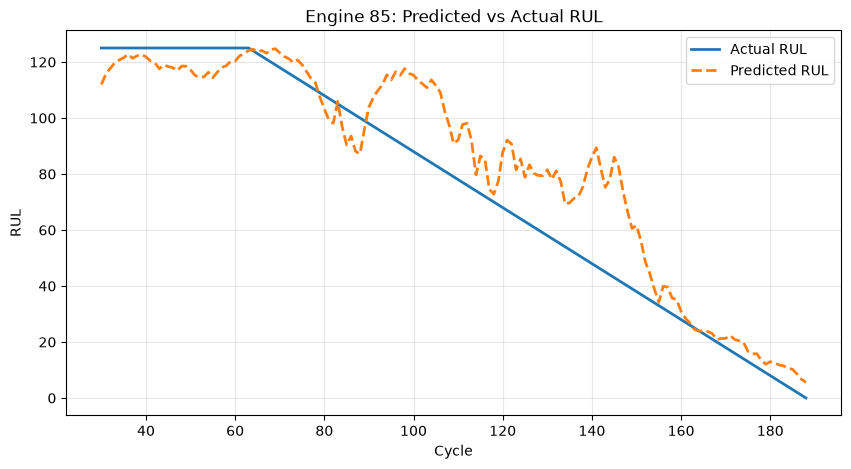

<Figure size 640x480 with 0 Axes>

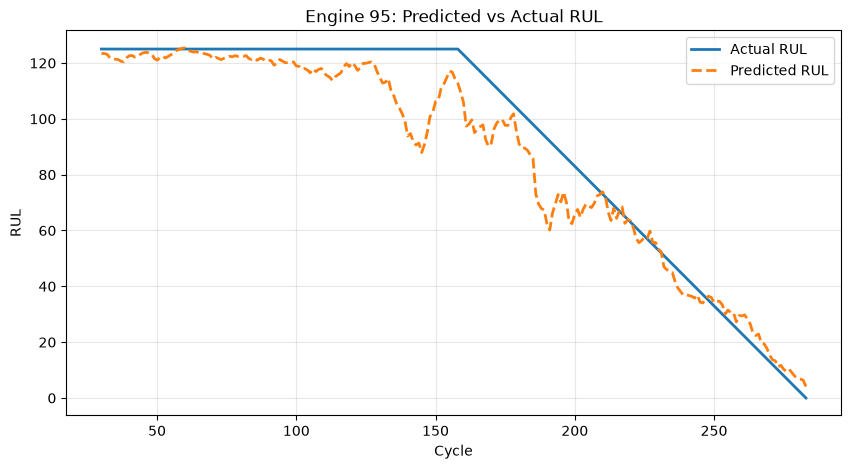

<Figure size 640x480 with 0 Axes>

In [28]:
plot_engine_predictions(85, df, model, feature_cols, window_size)
plt.savefig('engine_85_prediction.png', dpi=150, bbox_inches='tight')

plot_engine_predictions(95, df, model, feature_cols, window_size)
plt.savefig('engine_95_prediction.png', dpi=150, bbox_inches='tight')

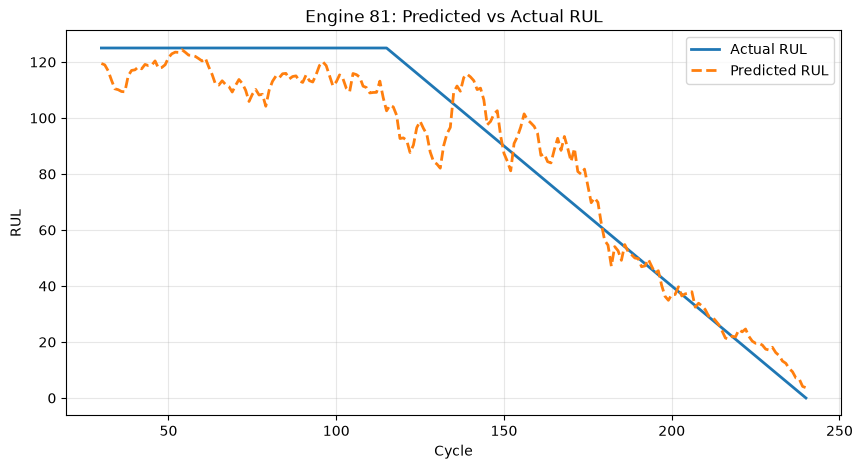

In [30]:
import matplotlib.pyplot as plt

def plot_engine_predictions(engine_id, df, model, feature_cols, window_size):
    engine_df = df[df['engine_id'] == engine_id].reset_index(drop=True)
    seqs, labs = create_sequences(engine_df, feature_cols, window_size)
    
    X_engine = np.array(seqs)
    y_actual = np.array(labs)
    y_pred = model.predict(X_engine, verbose=0).flatten()
    
    cycles = engine_df['cycle'].iloc[window_size - 1:].values
    
    plt.figure(figsize=(10, 5))
    plt.plot(cycles, y_actual, label='Actual RUL', linewidth=2)
    plt.plot(cycles, y_pred, label='Predicted RUL', linewidth=2, linestyle='--')
    plt.xlabel('Cycle')
    plt.ylabel('RUL')
    plt.title(f'Engine {engine_id}: Predicted vs Actual RUL')
    plt.legend()
    plt.grid(True, alpha=0.3)

# function call and save are outside the function, at the top level
plot_engine_predictions(81, df, model, feature_cols, window_size)
plt.savefig('engine_81_prediction.png', dpi=150, bbox_inches='tight')
plt.show()